In [1]:
#IMPORTS
import pandas as pd
from datetime import datetime
import time
from time import sleep
import re

from sympy.printing.pretty.pretty_symbology import unicode_warnings

from agents import *
from papers import *
import os
from datetime import datetime
import json

/opt/homebrew/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# get accession
df=pd.read_csv('data/example/example_data.csv')
accessions=df['Accession']

In [3]:
#Create library


# Create csv file
with open('results/library/library_summary.csv', 'w') as csvfile1:
    csvfile1.write(f'accession,number_of_papers,pmc_papers,pm_papers,duration(s)\n')

# Create txt file
with open('results/library/library_curation.txt', 'w') as infile:
    infile.write(f'Summary of the library Curation for example data\n{datetime.now()}\n\n')

# create library for all accessions
full_library_start=time.time()
for accession in accessions:
    # get start time
    start=time.time()
    # Create library
    CreateLibrary(accession)
    #End time
    end=time.time()
    #Duration
    duration=end-start

    #Number of papers
    papers=sorted(os.listdir(f'data/library/{accession}'))

    # Number of PMC papers
    pmc_papers=0
    for paper in papers:
        if paper.startswith('PMC'):
            pmc_papers+=1

    pm_papers=(len(papers)-pmc_papers)-1 # -1 for json

    with open(f'results/library/library_curation.txt','a') as f:
        f.write(f'\n\n\n================{accession}===============\n')
        f.write(f'Number of papers: {len(papers)}\n')
        f.write(f'Number of PMCs: {pmc_papers}\n')
        f.write(f'Number of PM papers: {pm_papers}\n')
        f.write(f'Duration: {round(duration,2)} seconds\n')

        f.write(f'======Paper Summary======\n')
        for paper in papers:
            with open(f'data/library/{accession}/{paper}','r') as infile:
                length=len(infile.read())
            f.write(f'{paper}\nNumber of characters: {length}\n')

    with open(f'results/library/library_summary.csv', 'a') as csvfile:
        csvfile.write(f'{accession},{len(papers)},{pmc_papers},{pm_papers},{duration}\n')




full_library_end=time.time()
full_duration=(full_library_end-full_library_start)/60
with open('results/library/library_curation.txt','a') as f:
    f.write(f'\n\nTotal Duration (minutes): {round(full_duration,2)}\n')

Tequatrovirus T4


KeyboardInterrupt: 

In [4]:
# Identify Bacterial Host from metadata

with open('results/host/host_classification.csv', 'w') as csvfile1:
    csvfile1.write(f'accession,host,taxonomic_level,reasoning,source,duration(m)\n')

with open('results/host/host_metadata_classification.txt','w') as f:
    f.write(f'Host classification of example data using metadata\n{datetime.now()}\n\n')

full_Start=time.time()
for accession in accessions:
    print(f'=============={accession}=============')
    with open(f"data/library/{accession}/{accession}.json", "r") as inj:
        metadata = json.load(inj)
        print(f'Metadata: {metadata}')

        # Define the start
    state = {
        'paper_text': None,
        'source_path': None,
        'model': 'qwen3.5',
        'metadata': metadata, # only including metadata
        'phage': None,
        'host_species': None,
        'reasoning': None,
        'confidence': None,
        'thermal_range': None,
        'temperature': None,
        'thermal_reasoning': None,
        'thermal_confidence': None,
    }

    start = time.time()
    output=HostMetadata(state)
    end=time.time()
    duration=(end-start)/60
    print(f'Accession: {accession}\nHost Species: {output.get("host_species", "unknown")}')
    print(f'Duration (minutes): {round(duration,2)}')
    print(f'LLM Output: {output}\n\n')

    if output.get('host_species', 'unknown') != 'unknown':
        source='metadata'
    else:
        source='unknown'


    reasoning=output.get('host_reasoning', 'unknown')
    reasoning=reasoning.replace(',', '')

    with open(f'results/host/host_classification.csv', 'a') as csvfile1:
        csvfile1.write(f"{accession},{output.get('host_species','unknown')},{output.get('taxon_level','unknown')},{reasoning},{source},{round(duration,2)}\n")

    with open(f'results/host/host_metadata_classification.txt', 'a') as f:
        f.write(f'==============={accession}==============\n')
        f.write(f'Host Species: {output.get("host_species", "unknown")}\n')
        f.write(f'Taxonomic Level: {output.get("taxon_level", "unknown")}\n')
        f.write(f'Reasoning: {output.get("host_reasoning", "unknown")}\n')
        f.write(f'Duration: {round(duration,2)} minutes\n')


full_end=time.time()
full_duration=(full_end-full_Start)/60

with open('results/host/host_metadata_classification.txt', 'a') as outf:
    outf.write(f'\n\nTotal Duration (minutes): {round(full_duration,2)}\n')


==============ADI87650=============
Metadata: {'uid': '298571302', 'accession': 'ADI87650', 'title': 'major head protein, partial [Tequatrovirus T4]', 'organism': 'Tequatrovirus T4', 'taxonId': 10665, 'sequence_length': 141, 'create_date': '2010/06/23', 'update_date': '2016/07/25', 'dbsource': 'insd', 'extra': 'gi|298571302|gb|ADI87650.1|', 'host': 'Enterobacteriales', 'old_name': 'Escherichia virus T4', 'map': 'between gp22 and SegD', 'clone': 's10-10', 'country': 'China: Donghu Lake, Wuhan'}
content='{\n    "host_species": "Enterobacteriales",\n    "found_in_metadata": true,\n    "taxon_level": "family",\n    "host_reasoning": "The metadata explicitly contains the key \'host\' with the value \'Enterobacteriales\'. According to the taxon_level rules, since \'Enterobacteriales\' is an order (often treated at the family level in broad contexts or strictly as an order, but the rule defines \'family\' as \'host is only given at family level (e.g. "Enterobacteriaceae")\', and this is the o

In [5]:
# Identify thermal range from metadata
with open('results/thermal/thermal_metadata_classification.txt', 'w') as outf:
     outf.write(f'Thermal classification of example data using accession metadata\n{datetime.now()}\n\n')

with open('results/thermal/thermal_classification.csv', 'w') as csvout:
    csvout.write('accession,thermal_range,inference_type,reasoning,confidence,source,duration(m)\n')

full_start=time.time()
for accession in accessions:
    print(f'=============={accession}=============')
    with open(f"data/library/{accession}/{accession}.json", "r") as f:
        metadata = json.load(f)
        print(f'Metadata: {metadata}')

        # Define the start
    state = {
        'paper_text': None,
        'source_path': None,
        'model': 'qwen3.5',
        'metadata': metadata, # only including metadata
        'phage': None,
        'host_species': None,
        'reasoning': None,
        'confidence': None,
        'thermal_range': None,
        'temperature': None,
        'thermal_reasoning': None,
        'thermal_confidence': None,
    }

    start = time.time()
    output=ThermalMetadata(state)
    end=time.time()
    duration=(end-start)/60
    print(f'\nThermal Range: {output.get("thermal_range", "unknown")}')
    print(f'Duration (minutes): {round(duration,2)}')
    print(f'LLM Output: {output}\n\n')

    if output.get('thermal_range', 'unknown') != 'unknown':
        source='metadata'
    else:
        source='unknown'

    reasoning=output.get("reasoning", "unknown")
    reasoning=reasoning.replace(',', '')

    with open(f'results/thermal/thermal_metadata_classification.txt', 'a') as f:
        f.write(f'==============={accession}==============\n')
        f.write(f'Thermal Range {output.get("thermal_range", "unknown")}\n')
        f.write(f'Inference Type {output.get("inference_type", "unknown")}\n')
        f.write(f'Reasoning {output.get("reasoning", "unknown")}\n')
        f.write(f'Confidence {output.get("confidence", "unknown")}\n')
        f.write(f'Duration: {round(duration,2)} minutes\n')


    with open(f'results/thermal/thermal_classification.csv', 'a') as f:
        f.write(f"{accession},{output.get('thermal_range', 'unknown')},{output.get('inference_type', 'unknown')},{reasoning},{output.get('confidence', 'unknown')},{source},{round(duration,2)}\n")

full_end=time.time()
full_duration=(full_end-full_start)/60

with open('results/thermal/thermal_metadata_classification.txt', 'a') as f:
    f.write(f'\n\nTotal Duration (minutes): {round(full_duration,2)}\n')

==============ADI87650=============
Metadata: {'uid': '298571302', 'accession': 'ADI87650', 'title': 'major head protein, partial [Tequatrovirus T4]', 'organism': 'Tequatrovirus T4', 'taxonId': 10665, 'sequence_length': 141, 'create_date': '2010/06/23', 'update_date': '2016/07/25', 'dbsource': 'insd', 'extra': 'gi|298571302|gb|ADI87650.1|', 'host': 'Enterobacteriales', 'old_name': 'Escherichia virus T4', 'map': 'between gp22 and SegD', 'clone': 's10-10', 'country': 'China: Donghu Lake, Wuhan'}
content='{\n    "thermal_range": "unknown",\n    "inference_type": "none",\n    "reasoning": "The metadata provides the host (\'Enterobacteriales\') and a specific sampling location (\'China: Donghu Lake, Wuhan\'). While Donghu Lake is a freshwater lake, the metadata does not explicitly state the water temperature, depth, or specific environmental conditions (e.g., \'deep water\', \'surface\', \'season\') that would allow for a definitive inference of psychrophile, mesophile, or thermophile statu

In [5]:
# CLASSIFYING HOST ORGANISM USING LITERATURE


patterns = {
    "infection_terms": r"\b(infects?|infecting|infected)\b",
    "isolation_terms": r"\b(isolated from|recovered from|obtained from|detected in)\b",
    "host_terms": r"\b(host bacterium|host bacteria|bacterial host)\b",
    "phage_of": r"\bphage (?:of|infecting)\b",
}

df=pd.read_csv('results/host/host_classification.csv')
accessions=df[df['host']=='unknown']['accession']

with open(f'results/host/host_literature_classification.txt', 'w') as outfile:
    outfile.write('Host Classification of Example data using first literature creation\n')
    outfile.write(f'Attempts to classify the accessions not classified from metadata search\n')
    outfile.write(f'Uses the first literature creation pulled from the protein accession\n')
    outfile.write(f'{datetime.now()}\n')


full_start=time.time()
for accession in accessions:
    acc_start=time.time()
    with open(f'results/host/host_literature_classification.txt', 'a') as f:
        f.write(f'======================{accession}======================\n')

    rankings=RankPapers(f'data/library/{accession}/', patterns)

    prev_duration=df[df['accession']==accession]['duration(m)'].values[0]

    with open(f'data/library/{accession}/{accession}.json', 'r') as f:
        metadata = json.load(f)

    papers=list(rankings.keys())
    host_high_confidence = False

    for paper in papers:
        with open(f'data/library/{accession}/{paper}') as f:
            paper_text = f.read()

        state = {
            'paper_text': paper_text,
            'source_path': f'data/library/{accession}/{paper}',
            'model': 'qwen3.5',
            'metadata': metadata,
            'phage': metadata.get('organism', 'unknown'),
            'host_species': None,
            'reasoning': None,
            'confidence': None,
            'thermal_range': None,
            'temperature': None,
            'thermal_reasoning': None,
            'thermal_confidence': None,
        }

        start = time.time()
        host_classification = IdentifyHost(state)
        print(f'LLM output After JSONIFICATION: {host_classification}')
        end = time.time()
        duration=(end-start)/60


        host=host_classification.get('host_species','unknown')
        reasoning=host_classification.get('host_reasoning','unknown')
        confidence=host_classification.get('host_confidence','unknown')

        reasoning=reasoning.replace(',', '')


        with open(f'results/host/host_literature_classification.txt', 'a') as f:
            f.write(f'===================\nPaper: {paper}\tPaper Score: {rankings[paper]["total"]}\n')
            f.write(f'Host Species: {host}\n')
            f.write(f'Reasoning: {reasoning}\n')
            f.write(f'Confidence: {confidence}\n')
            f.write(f'Duration: {round(duration,2)}\n')

        if host != 'unknown' and confidence == 'high':
            host_high_confidence = True
            df.loc[df['accession'] == accession, 'host'] = host
            df.loc[df['accession'] == accession, 'duration(m)'] = prev_duration + duration
            df.loc[df['accession'] == accession, 'source'] = 'literature'
            df.loc[df['accession'] == accession, 'reasoning'] = reasoning
            break


    if not host_high_confidence:
        df.loc[df['accession'] == accession, 'host'] = 'unknown'


    acc_end=time.time()
    acc_duration=(acc_end-acc_start)/60
    with open(f'results/host/host_literature_classification.txt', 'a') as f:
        f.write(f'\nFull Accession Duration: {round(acc_duration,2)}minutes\n')

full_end=time.time()
full_duration=(full_end-full_start)/60
with open('results/host/host_literature_classification.txt', 'a') as f:
    f.write(f'\n\nTotal Duration (minutes): {round(full_duration,2)}')

df.to_csv('results/host/host_classification.csv')



LLM OUTPUT: content='{\n  "host_species": "Acinetobacter baumannii",\n  "taxonomic_level": "species",\n  "host_reasoning": "The paper explicitly states that the phage vB_AbaM_MU1 was isolated and characterized against \'Acinetobacter baumannii\' strains. Specifically, the text mentions: \'A novel lytic Acinetobacter phage vB_AbaM_MU1 was isolated... It showed lytic efficiency against 9/17 CRAB strains.\' The \'Materials and methods\' section further clarifies: \'Eighteen CRAB clinical isolates were obtained... Acinetobacter baumannii M13 isolate... was selected as the host strain\'. The abbreviation \'CRAB\' is defined in the text as \'Carbapenem-resistant Acinetobacter baumannii\'. The host range analysis was conducted against \'A. baumannii\' strains and other genera, confirming the specific host is Acinetobacter baumannii.",\n  "host_confidence": "high"\n}' additional_kwargs={} response_metadata={'model': 'qwen3.5', 'created_at': '2026-04-29T17:06:18.056044Z', 'done': True, 'done_re

In [3]:
# Classify Thermal Range using initial literature search
from papers import *
from datetime import datetime
import pandas as pd
import time
from agents import IdentifyThermalRange

patterns = {
    # organisms
    "mesophile": r"\bmesophil(?:e|ic|es|icity)?\b",
    "psychrophile": r"\bpsychrophil(?:e|ic|es|icity)?\b",
    "thermophile": r"\bthermophil(?:e|ic|es|icity)?\b",
    # temperature concepts
    "temperature": r"\btemperatur(e|es)?\b",
    "optimal_growth": r"\boptimal(?:ly)?\s+(growth|temperature|growing)\b",
    # units
    "celsius": r"\b\d+(?:\.\d+)?\s?°?\s?[Cc]\b|\bCelsius\b",
    "kelvin": r"\b\d+(?:\.\d+)?\s?[Kk]\b|\bKelvin\b"
}

df=pd.read_csv('results/thermal/thermal_classification.csv')
accessions=df[df['thermal_range']=='unknown']['accession']

host_df=pd.read_csv('results/host/host_classification.csv')

with open(f'results/thermal/thermal_literature_classification.txt', 'w') as outfile:
    outfile.write('Thermal Classification of Example data using first literature creation\n')
    outfile.write(f'Attempts to classify the accessions not classified from metadata search\n')
    outfile.write(f'Uses the first literature creation pulled from the protein accession, not literature of the host\n')
    outfile.write(f'{datetime.now()}\n')

full_Start=time.time()
for accession in accessions:
    acc_start=time.time()
    with open(f'results/thermal/thermal_literature_classification.txt', 'a') as f:
        f.write(f'======================{accession}======================\n')

    rankings=RankPapers(f'data/library/{accession}/', patterns)

    host=host_df[host_df['accession']==accession]['host'].values[0]

    prev_duration=df[df['accession']==accession]['duration(m)'].values[0]


    with open(f'data/library/{accession}/{accession}.json', 'r') as f:
        metadata = json.load(f)

    papers=list(rankings.keys())
    thermal_high_confidence = False

    for paper in papers:
        with open(f'data/library/{accession}/{paper}') as f:
            paper_text = f.read()


        state = {
            'paper_text': paper_text,
            'source_path': f'data/library/{accession}/{paper}',
            'model': 'qwen3.5',
            'metadata': metadata,
            'phage': metadata.get('organism', 'unknown'),
            'host_species': host,
            'reasoning': None,
            'confidence': None,
            'thermal_range': None,
            'temperature': None,
            'thermal_reasoning': None,
            'thermal_confidence': None,
        }

        start = time.time()
        thermal_classification = IdentifyThermalRange(state)
        print(f'LLM output: {thermal_classification}\n\n')
        end = time.time()
        duration=(end-start)/60

        thermal_range=thermal_classification.get('thermal_range', 'unknown')
        temperature=thermal_classification.get('temperature', 'unknown')
        reasoning=thermal_classification.get('thermal_reasoning', 'unknown')
        confidence=thermal_classification.get('thermal_confidence', 'unknown')

        reasoning=reasoning.replace(',', '')

        with open(f'results/thermal/thermal_literature_classification.txt', 'a') as f:
            f.write(f'===================\nPaper: {paper}\tPaper Score: {rankings[paper]["total"]}\n')
            f.write(f'Thermal Range: {thermal_range}\n')
            f.write(f'Temperature: {temperature}\n')
            f.write(f'Reasoning: {reasoning}\n')
            f.write(f'Confidence: {confidence}\n')
            f.write(f'Duration (minutes): {round(duration,2)}\n\n')

        if thermal_range != 'unknown' and confidence == 'high':
            thermal_high_confidence = True
            df.loc[df['accession'] == accession, 'thermal_range'] = thermal_range
            df.loc[df['accession'] == accession, 'duration(m)'] = prev_duration + duration
            df.loc[df['accession'] == accession, 'source'] = 'literature'
            df.loc[df['accession'] == accession, 'reasoning'] = reasoning
            break

    if not thermal_high_confidence:
        df.loc[df['accession'] == accession, 'thermal_range'] = 'unknown'

    acc_end=time.time()
    acc_duration=(acc_end-acc_start)/60
    with open(f'results/thermal/thermal_literature_classification.txt', 'a') as f:
        f.write(f'\nFull Accession Duration: {round(acc_duration,2)}minutes\n')
full_end=time.time()
full_duration=(full_end-full_Start)/60
with open('results/thermal/thermal_literature_classification.txt', 'a') as f:
    f.write(f'\n\nTotal Duration (minutes): {round(full_duration,2)}')

df.to_csv('results/thermal/thermal_classification.csv')

LLM output: {}
LLM output: {'thermal_range': 'mesophile', 'temperature': '21–37 °C', 'thermal_reasoning': "The paper explicitly states that phage JC53 (the organism in question) 'effectively lysed EV76 at 28 °C, 21 °C, and 37 °C' (Section 3.1). Additionally, Section 3.2.1 notes that activity remained stable below 60 °C and was lost at 70 °C. Section 2.6 confirms host range assays were conducted at 21 °C, 28 °C, and 37 °C, with lysis observed at all three temperatures. These temperatures fall within the mesophile range (15–45 °C). No data support psychrophile (<15 °C) or thermophile (>45 °C) classification.", 'thermal_confidence': 'high'}
LLM output: {'thermal_range': 'mesophile', 'temperature': '30 °C', 'thermal_reasoning': "The paper explicitly states that experiments were conducted at specific temperatures, including 30 °C, 24 °C, and 37 °C. Specifically, the text mentions: 'We chose nanoliter unit as it better reflects the small total volume of encapsulated CFE reaction into the SCs

In [16]:
# Last attempt at classifying based on metadata (forced classification)
# IDENTIFYING THE THERMAL RANGE OF PHAGE FROM METADATA

from no_context import *
from tools import *
import pandas as pd
import time

df=pd.read_csv('results/thermal/thermal_classification.csv')
accessions=df[df['thermal_range']=='unknown']['accession']

with open(f'results/thermal/thermal_forced_classification.txt','w') as f:
    f.write(f'Classifying thermal range of bacteriophage using only the metadata\n')
    f.write(f'Forced output, must return a classification\n')

full_start=time.time()
for accession in accessions:
    with open(f'results/thermal/thermal_forced_classification.txt','a') as f:
        f.write(f'============={accession}=============\n')
    metadata=FetchNcbiMetadata(accession)

    state = {
            'paper_text': None,
            'source_path': None,
            'model': 'qwen3.5',
            'metadata': metadata,
            'phage': metadata.get('organism', 'unknown'),
            'host_species': None,
            'reasoning': None,
            'confidence': None,
            'thermal_range': None,
            'temperature': None,
            'thermal_reasoning': None,
            'thermal_confidence': None,
        }
    acc_start=time.time()
    out=IdentifyThermalRangeNoContext(state)
    acc_end=time.time()
    acc_duration=(round(acc_end-acc_start,2)/60)
    print(f'{accession}: {out.get("thermal_range")}')


    thermal_range=out.get('thermal_range')

    df.loc[df['accession'] == accession, 'thermal_range'] = thermal_range
    df.loc[df['accession'] == accession, 'duration(m)'] = prev_duration + duration
    df.loc[df['accession'] == accession, 'source'] = 'forced'
    df.loc[df['accession'] == accession, 'reasoning'] = 'forced from metadata'

    with open(f'results/thermal/thermal_forced_classification.txt','a') as f:
        f.write(f'Thermal Classification: {out.get("thermal_range", "unknown")}\n')
        f.write(f'Duration: {acc_duration}\n')

full_end=time.time()
full_duration=(round(full_end-full_start,2)/60)
with open(f'results/thermal/thermal_forced_classification.txt','a') as f:
    f.write(f'\n\nFull Duration: {full_duration} minutes\n')


df.to_csv('results/thermal/thermal_classification.csv')

LLM OUTPUT: content='{\n  "thermal_range": "mesophile"\n}' additional_kwargs={} response_metadata={'model': 'qwen3.5', 'created_at': '2026-04-30T12:34:26.34521Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1678638834, 'load_duration': 100665834, 'prompt_eval_count': 360, 'prompt_eval_duration': 1079749916, 'eval_count': 14, 'eval_duration': 491901041, 'logprobs': None, 'model_name': 'qwen3.5', 'model_provider': 'ollama'} id='lc_run--019dde62-1b18-7480-85e7-93b7f59f3d6b-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 360, 'output_tokens': 14, 'total_tokens': 374}
SNQ28030: mesophile
LLM OUTPUT: content='{\n  "thermal_range": "psychrophile"\n}' additional_kwargs={} response_metadata={'model': 'qwen3.5', 'created_at': '2026-04-30T12:34:29.457876Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1677735458, 'load_duration': 82064917, 'prompt_eval_count': 362, 'prompt_eval_duration': 1078617291, 'eval_count': 15, 'eval_duration': 509639291, 'logpro

In [51]:
# Create confusion matrix
y_true=list(pd.read_csv('results/thermal/thermal_classification.csv')['thermal_range'])
y_pred=list(pd.read_csv('data/example/example_data.csv')['Thermal Range'])


In [122]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

def ConfusionMatrix(y_true, y_pred):
    """
    Create and display a confusion matrix from two lists.
    """
    unique_labels = sorted(set(y_true) | set(y_pred))
    n_labels = len(unique_labels)

    # Initialize matrix
    cm = np.zeros((n_labels, n_labels), dtype=int)



    for true_label, pred_label in zip(y_true, y_pred):
        true_idx = unique_labels.index(true_label)
        pred_idx = unique_labels.index(pred_label)
        cm[true_idx, pred_idx] += 1


    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)


    return disp



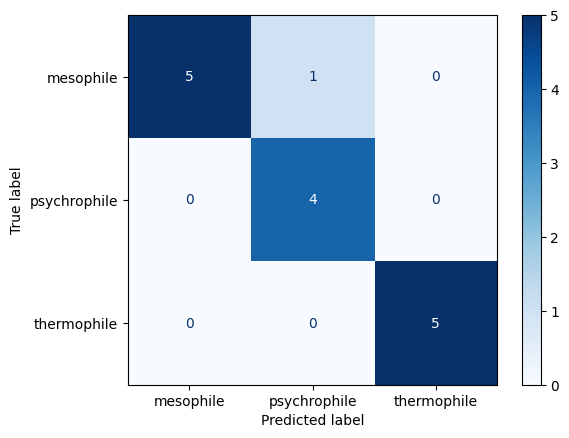

In [130]:
import matplotlib.pyplot as plt

plot=ConfusionMatrix(y_true, y_pred)
plot.plot(cmap='Blues')
plt.savefig('results/thermal/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [121]:
from sklearn.metrics import classification_report

with open(f'results/thermal/thermal_statistics.txt','w') as f:
    f.write(classification_report(y_true, y_pred))